In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as sp_linalg

import pymgrit
from pymgrit.core.mgrit import Mgrit

from time import time
import json

from src.parareal import Parareal
from src.ncorposapp import NCorpos

import ncorpos_utilidades as nut

caminho_pymgrit = "saida"

# Funções

In [21]:
def ler_vi_json (arquivo:str):
    with open(arquivo, 'r') as arq:
        arq_json = json.load(arq)
    massas = arq_json['valores_iniciais']['massas']
    posicoes = arq_json['valores_iniciais']['posicoes']
    momentos = arq_json['valores_iniciais']['momentos']
    return np.array(massas), np.array(posicoes), np.array(momentos)

def converter_3d_para_2d (vetor):
    return vetor[:,:-1]    

In [22]:
## Função para armazenar a solução do método Parareal em cada iteração
def output_parareal(self):
    ## Nome do arquivo de saída
    fname = 'ncorpos_iter' + str(self.solve_iter) + '_rank' + str(self.comm_time_rank)
    fname = caminho_pymgrit + "/" + fname
    # Salva a solução em um arquivo
    np.save(fname,
                [[[self.t[0][i], self.u[0][i]] for i in self.index_local[0]]])

## Função para armazenar a solução de referência
def output_ref(self):
    # Nome do arquivo de saída
    fname = 'ncorpos_ref_rank' + str(self.comm_time_rank)
    fname = caminho_pymgrit + "/" + fname
    # Salva a solução em um arquivo
    np.save(fname,
                [[[self.t[0][i], self.u[0][i]] for i in self.index_local[0]]])

def aplicar_parareal (parametros:dict, tol:bool=False):
    # u0
    q0, p0 = parametros["vi"]["posicoes"], parametros["vi"]["momentos"]
    u0 = np.array([q0, p0])

    # Numero de janelas dos metodos
    nt_slices = parametros["num_janelas"] + 1
    nt_fino = parametros["multip_fino"] * (nt_slices - 1) + 1
    nt_gros = parametros["multip_grosseiro"] * (nt_slices - 1) + 1
    N_dt_per_slice = int((nt_fino-1)/(nt_slices-1))

    # Se for usar um valor de tolerancia
    tolerancia = 0.0
    if tol:
        tolerancia = ((parametros["tf"] - parametros["t0"])/nt_fino)**parametros["ordem"]

    # Instancia do nivel 0
    ncorpos_level_0 = NCorpos(
        G       = parametros["G"],
        eps     = parametros["amortecedor"],
        massas  = parametros["vi"]["massas"],
        u0      = u0,
        t_start = parametros["t0"],
        t_stop  = parametros["tf"],
        method  = parametros["metodo_fino"],
        nt      = nt_fino
    )

    # Instancia do nivel 1
    ncorpos_level_1 = NCorpos(
        G       = parametros["G"],
        eps     = parametros["amortecedor"],
        massas  = parametros["vi"]["massas"],
        u0      = u0,
        t_start = parametros["t0"],
        t_stop  = parametros["tf"],
        method  = parametros["metodo_grosseiro"],
        nt      = nt_gros
    )

    # Array contendo todos os niveis de discretização
    problema = [ncorpos_level_0, ncorpos_level_1]

    # Instancia do Parareal
    parareal = Parareal(
        problem = problema,
        nt_slices = nt_slices,
        max_iter = parametros["max_iter"],
        output_parareal=output_parareal,
        tol = tolerancia
    )

    # Agora executa
    tempo_parareal = time()
    info_pint = parareal.solve()
    tempo_parareal = time() - tempo_parareal

    # Tambem roda a simulacao de referencia
    problema_referencia = [ncorpos_level_0]
    mgrit_ref = Mgrit(
        problem = problema_referencia,
        output_fcn = output_ref,
        max_iter = 1
    )
    tempo_referencia = time()
    info_ref = mgrit_ref.solve()
    tempo_referencia = time() - tempo_referencia

    return {
        "tempo_parareal": tempo_parareal,
        "tempo_referencia": tempo_referencia,
        "info_pint": info_pint,
        "info_ref": info_ref,
        "N_dt_per_slice": N_dt_per_slice
    }

In [23]:
def pp_referencia ():
    ######################################
    ## Leitura da solução de referência ##
    ######################################
    sol_ref = np.load(caminho_pymgrit + "/ncorpos_ref_rank0.npy", allow_pickle=True).tolist()[0]

    ## Extrair os instantes de tempo nos quais a solução está calculada (primeira coluna),
    ## guardando apenas os instantes definindo as janelas de tempo
    ## (por padrão, pymgrit retorna a solução em toda a discretização temporal fina)
    ts_ref = np.array([j[0] for j in sol_ref])

    ## Extrair a solução em cada instante de tempo (segunda coluna)
    us_ref = np.array([j[1].get_values() for j in sol_ref])

    ## Ordernar em tempo crescente
    idx = np.argsort(ts_ref)
    ts_ref = ts_ref[idx]
    us_ref = us_ref[idx]

    return ts_ref, us_ref

def pp_pint (info_pint):
    ####################################################
    ## Determinação do número de iterações realizadas ##
    ####################################################
    total_iterations = len(info_pint['conv']) + 1

    ####################################################
    ## Leitura da solução do método paralelo no tempo ##
    ####################################################
    sol_pint = []
    # Percorrer as iterações
    for i in range(total_iterations):
        # Ler a solução da iteração na forma de pares (t_i, y_i)
        sol_iteration = []
        sol_iteration += np.load(caminho_pymgrit + "/ncorpos_iter" + str(i) + "_rank0.npy", allow_pickle=True).tolist()[0]
        
        # Ler os instantes definindo as janelas de tempo (primeira coluna)
        ts = np.array([j[0] for j in sol_iteration])
        # Ler as respectivas soluções (segunda coluna)
        us = np.array([j[1].get_values() for j in sol_iteration])
        
        # Ordenar em tempo crescente
        idx = np.argsort(ts)
        ts = ts[idx]
        us = us[idx]
        
        # Concatena a solução da iteração ao final da lista completa
        sol_pint.append([ts, us])
    
    return sol_pint

In [24]:
def plotar_trajetorias (us, quais_plotar:list=[], label=""):
    # Separa a solucao em particulas
    posicoes = np.array(list(zip(*us)))[0]
    corpos = np.array(list(zip(*posicoes)))

    if len(quais_plotar) == 0: 
        quais_plotar = [{"ind": i, "traco": 0, "cor": 0} for i in range(len(corpos))]
    for qual in quais_plotar:
        corpo = corpos[qual["ind"]]
        x, y = list(zip(*corpo))

        cor = qual["cor"]
        traco = qual["traco"]
        if traco == 0: traco = "-"

        if cor != 0: 
            if len(label) > 0:
                plt.plot(x, y, traco, c=cor, label=label)
            else:
                plt.plot(x, y, traco, c=cor)
        else: 
            if len(label) > 0:
                plt.plot(x, y, traco, label=label)
            else:
                plt.plot(x, y, traco)

def plotagem_pint (sol_pint, quais_iteracoes:list=[], quais_plotar:list=[]):
    if len(quais_iteracoes) == 0: quais_iteracoes = range(len(sol_pint))
    if len(quais_plotar) == 0: quais_plotar = range(len(sol_pint[0]))
    
    for ind_iter in quais_iteracoes:
        ts, us = sol_pint[ind_iter]

        plotar_trajetorias(us, [
            {"ind": i, "traco": 0, "cor":0}
            for i in quais_plotar
        ], r'$k={}$'.format(ind_iter))

def plotagem_referencia (us_ref, quais_plotar:list=[]):
    plotar_trajetorias(us_ref, [
        {"ind": i, "traco": "--", "cor":"black"}
        for i in quais_plotar
    ])

In [25]:
def calcular_erros (ts_ref, us_ref, sol_pint, fatias:int):
    # ##########################################################
    # ## Cálculo dos erros em relação à solução de referência ##
    # ## (solução sequencial do modelo fino)                  ##
    # ##########################################################
    # Erro nos instante final
    erro_pint_ref_T = []

    # Percorrer as iteracoes e calcular o erro relativo
    for i in range(len(sol_pint)):
        erro = np.linalg.norm(sol_pint[i][1][-1] - us_ref[-1])
        erro = erro / np.linalg.norm(us_ref[-1])
        erro_pint_ref_T.append(erro)
    
    # Erro ao longo do tempo em cada iteração em relacao a solucao
    # de referencia
    ts_ref_fatiado = ts_ref[::fatias]
    us_ref_fatiado = us_ref[::fatias]
    erro_pint_ref_tk = np.empty((len(sol_pint), ts_ref_fatiado.shape[0]))
    # Percorre as iteracoes e armazenaos erros
    for i in range(len(sol_pint)):
        erro_lista = [
            np.linalg.norm(sol_pint[i][1][::fatias][j] - us_ref_fatiado[j])
            for j in range(len(us_ref_fatiado))
        ]
        erro_pint_ref_tk[i,:] = np.array(erro_lista)
    
    return erro_pint_ref_T, erro_pint_ref_tk

def plotar_erros_final (erro_pint_ref_T):
    plt.figure()
    plt.plot(erro_pint_ref_T, label = r'$|u^k_{N} - u_{ref,N}|/|u_{ref,N}|$', marker = 'o')
    plt.xlabel('Iteração')
    plt.ylabel('Erro ')
    plt.yscale('log')
    plt.legend()
    plt.show()

def plotar_erros_processo (ts_ref, erro_pint_ref_tk, fatias):
    ts_ref_fatiado = ts_ref[::fatias]
    plt.figure()

    for i, erro in enumerate(erro_pint_ref_tk):
        plt.plot(ts_ref_fatiado, erro, label=r'$k={}$'.format(i))
        
    plt.yscale('log')
    plt.xlabel(r'$t$')
    plt.ylabel('Erro ' + r'$|u^k_n - u_{ref,n}|/|u_{ref,n}|$')
    plt.legend()
    plt.show()

# Aplicação

In [26]:
#### Problema de 3 corpos - Lemniscata
G, eps = 1, 0
massas = np.ones(3)
q0 = np.array([
    [-0.97000436,  0.24308753],
    [0.0,         0.0,       ],
    [0.97000436, -0.24308753]
])
p0 = np.array([
    [0.4662036850, 0.4323657300],
    [-0.93240737,  -0.86473146],
    [ 0.4662036850, 0.4323657300]
])


#### Problema de 5 corpos - Coreografia
# G, eps = 1, 0
# massas, q0, p0 = ler_vi_json('CCNMAS5_1.json')
# q0 = converter_3d_para_2d(q0)
# p0 = converter_3d_para_2d(p0)


#### Problema de 12 corpos - Coreografia
# G, eps = 1, 0
# massas, q0, p0 = ler_vi_json('CCNMAS12_1.json')
# q0 = converter_3d_para_2d(q0)
# p0 = converter_3d_para_2d(p0)


#### Problema de 5 corpos - PDF do João
# G, eps = 1.0, 0.0
# massas = np.ones(5)
# q0 = np.array([[-1., 0.], [0., -1.], [1., 0.], [0., 1.], [0.0, 0.0]])
# p0 = np.array([[0., -1.], [1., 0.], [0., 1.], [-1., 0.], [0.0, 0.0]])



# Integrais primeiras
E0 = nut.energia_total(massas, q0, p0, G, eps)
J0 = nut.momento_angular_total(q0, p0)

In [27]:
parametros = {
    # Valores iniciais e parametros de N-corpos
    "G": G, "amortecedor": eps,
    "vi": {
        "massas": massas,
        "posicoes": q0,
        "momentos": p0
    },

    # Intervalo de integracao
    "t0": 0, 
    "tf": 10,

    # Quantidade de janelas
    "num_janelas": 20,
    
    # Numero maximo de iteracoes
    "max_iter": 20,

    # Metodo fino
    "metodo_fino": "ruth4",
    "multip_fino": 32,
    "ordem": 4,

    # Metodo grosseiro
    "metodo_grosseiro": "euler_simp",
    "multip_grosseiro": 2
}

infos = aplicar_parareal(parametros, tol=True)

SHAPE DO U0: (2, 3, 2)
SHAPE DO U0: (2, 3, 2)
INFO - 20-02-26 12:03:22 - Start setup
INFO - 20-02-26 12:03:22 - Setup took 0.017895221710205078 s
INFO - 20-02-26 12:03:22 - Start solve
INFO - 20-02-26 12:03:22 - iter 1  | conv: 12.25464475317671       | conv factor: -                     | runtime: 0.10077118873596191 s  
INFO - 20-02-26 12:03:22 - iter 2  | conv: 159.1996273556438       | conv factor: 12.990962248365078    | runtime: 0.05104374885559082 s  
INFO - 20-02-26 12:03:22 - iter 3  | conv: 7.719409566961282       | conv factor: 0.048488867060703086  | runtime: 0.050748348236083984 s 
INFO - 20-02-26 12:03:22 - iter 4  | conv: 14.930993940407022      | conv factor: 1.934214503180527     | runtime: 0.05109906196594238 s  
INFO - 20-02-26 12:03:23 - iter 5  | conv: 94.95274017102797       | conv factor: 6.359438664968042     | runtime: 0.051207542419433594 s 
INFO - 20-02-26 12:03:23 - iter 6  | conv: 46.76949979190271       | conv factor: 0.49255555666599965   | runtime: 0.051

E0: -1.2871419917663258
TEMPO PARAREAL:  1.1153299808502197
TEMPO SEQUENCIAL:  0.0523838996887207
S:  0.046967176161433664
Erro relativo na energia da referencia: 1.1537563050546774e-07


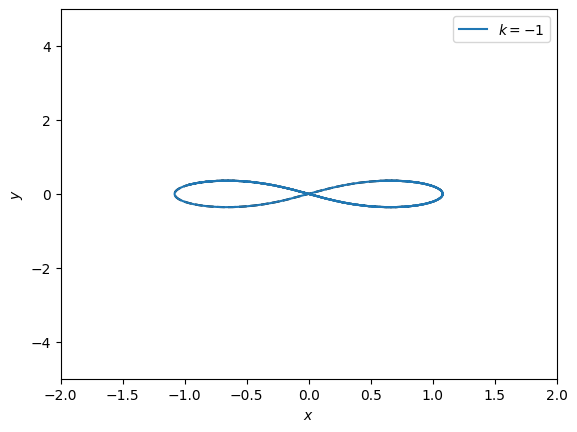

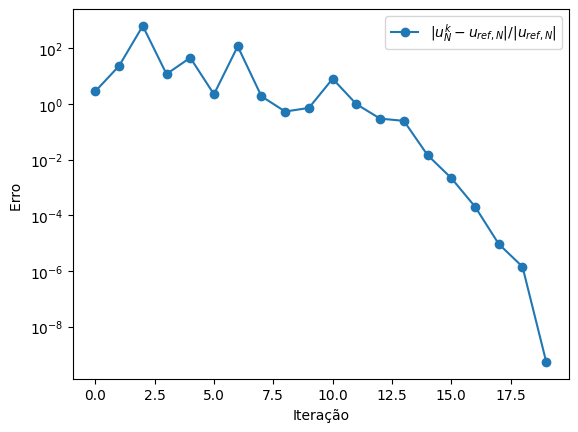

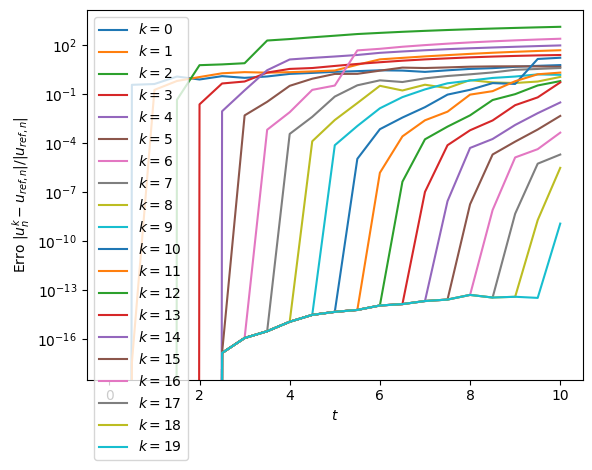

In [28]:
print("E0:", E0)
print("TEMPO PARAREAL: ", infos["tempo_parareal"])
print("TEMPO SEQUENCIAL: ", infos["tempo_referencia"])
print("S: ", infos["tempo_referencia"] / infos["tempo_parareal"])

# Pós-processamento
ts_ref, us_ref = pp_referencia()
sol_pint = pp_pint(infos['info_pint'])

# Erro nas integrais primeiras da referencia
q_ref,p_ref = np.array(list(zip(*us_ref)))
E_ref = nut.energia_total(massas, q_ref[-1], p_ref[-1], G, eps)
J_ref = nut.momento_angular_total(q_ref[-1], p_ref[-1])
print("Erro relativo na energia da referencia:", abs(E_ref - E0)/abs(E_ref))

# Plotando
plotagem_referencia(us_ref, [0])

plotagem_pint(sol_pint, 
    # quais_iteracoes= [i for i in range(len(sol_pint)) if i % 4 == 0 and i > 0], 
    quais_iteracoes = [-1],
    quais_plotar   = [ 0 ]
    )

plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

plt.legend()
plt.xlim(-2,2)
plt.ylim(-5,5)
plt.show()

## Erros
erro_final, erro_durante = calcular_erros(ts_ref, us_ref, sol_pint, infos["N_dt_per_slice"])
plotar_erros_final(erro_final)
plotar_erros_processo(ts_ref, erro_durante, infos["N_dt_per_slice"])